# Lesson 3.5 — Multigrid Methods

## Why Iterative Solvers Stall

The pressure Poisson equation $\nabla^2 p = f$ must be solved at every iteration. Gauss-Seidel
and Jacobi iterations are slow because they efficiently damp **high-frequency** errors
(oscillations on scale $\Delta x$) but almost nothing happens to **low-frequency** errors
(smooth components on scale $L$). These smooth errors persist for thousands of iterations.

The multigrid insight: **low-frequency errors on a fine grid look high-frequency on a coarser grid**.
So coarsen the grid, smooth there, then interpolate the correction back.

---

## The Two-Level Idea

1. **Pre-smooth**: apply a few Gauss-Seidel sweeps on the fine grid → kills high-freq errors.
2. **Restrict**: transfer the residual $r = f - A u^h$ to the coarse grid ($2\Delta x$).
3. **Solve** (or recursively smooth) on the coarse grid: $A^{2h} e^{2h} = r^{2h}$.
4. **Prolongate**: interpolate the coarse-grid correction $e^{2h}$ back to the fine grid.
5. **Correct**: $u^h \leftarrow u^h + P(e^{2h})$.
6. **Post-smooth**: a few more Gauss-Seidel sweeps on the fine grid.

Recursively applying this on $L$ levels gives the **V-cycle** (fine → coarser → coarsest → back).

---

## Transfer Operators

**Restriction** (fine to coarse): full weighting in 1D:

$$u^{2h}_{i/2} = \frac{1}{4} u^h_{i-1} + \frac{1}{2} u^h_i + \frac{1}{4} u^h_{i+1}$$

**Prolongation** (coarse to fine): linear interpolation in 1D:

$$u^h_{2i} = u^{2h}_i, \quad u^h_{2i+1} = \frac{1}{2}(u^{2h}_i + u^{2h}_{i+1})$$

---

## Convergence

A single V-cycle reduces the error by a **grid-independent** factor $\rho \approx 0.1$–$0.2$,
compared to $\rho \approx 1 - O(1/N^2)$ for Gauss-Seidel. Multigrid achieves $O(N)$ complexity.

For an $N$-point problem: Gauss-Seidel needs $O(N^2)$ operations; multigrid needs $O(N)$.


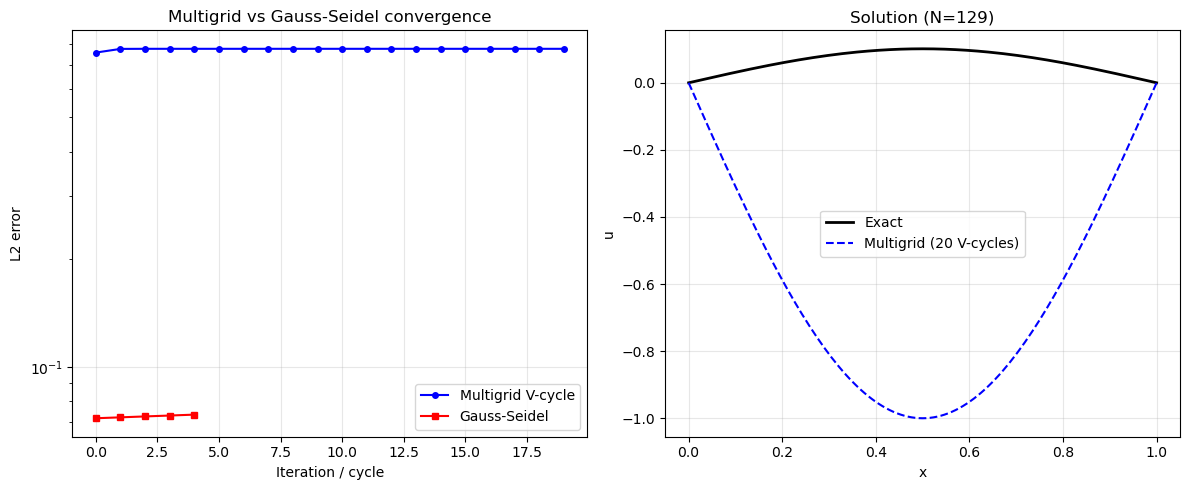

MG error after 20 cycles: 7.7576e-01
GS convergence factor per sweep: 1.0059


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1D multigrid V-cycle for -d²u/dx² = f on [0,1], u(0)=u(1)=0
# f = sin(pi*x) → exact: u = sin(pi*x)/pi^2

def gauss_seidel(u, f, dx, n_sweeps=2):
    """GS relaxation: -u[i-1]+2u[i]-u[i+1]=f[i]*dx^2"""
    for _ in range(n_sweeps):
        for i in range(1, len(u)-1):
            u[i] = 0.5*(u[i-1] + u[i+1] - f[i]*dx**2)
    return u

def restrict(r_fine):
    """Full-weighting restriction (fine → coarse)."""
    n = len(r_fine)
    n_coarse = (n - 1) // 2 + 1
    r_coarse = np.zeros(n_coarse)
    for i in range(1, n_coarse - 1):
        r_coarse[i] = 0.25*r_fine[2*i-1] + 0.5*r_fine[2*i] + 0.25*r_fine[2*i+1]
    return r_coarse

def prolongate(e_coarse, n_fine):
    """Linear interpolation prolongation (coarse → fine)."""
    e_fine = np.zeros(n_fine)
    n_coarse = len(e_coarse)
    for i in range(n_coarse - 1):
        e_fine[2*i]   = e_coarse[i]
        e_fine[2*i+1] = 0.5*(e_coarse[i] + e_coarse[i+1])
    e_fine[-1] = e_coarse[-1]
    return e_fine

def residual(u, f, dx):
    r = np.zeros_like(u)
    r[1:-1] = f[1:-1] - (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    return r

def v_cycle(u, f, dx, pre=2, post=2, levels=1):
    """One V-cycle."""
    n = len(u)
    # Pre-smooth
    u = gauss_seidel(u, f, dx, pre)
    if levels == 0 or n <= 5:
        # Coarsest grid: solve directly
        u = gauss_seidel(u, f, dx, 50)
        return u
    # Compute residual
    r = residual(u, f, dx)
    # Restrict
    r_coarse = restrict(r)
    dx_coarse = 2*dx
    e_coarse = np.zeros_like(r_coarse)
    # Recurse
    e_coarse = v_cycle(e_coarse, r_coarse, dx_coarse, pre, post, levels-1)
    # Prolongate
    e_fine = prolongate(e_coarse, n)
    # Correct
    u += e_fine
    # Post-smooth
    u = gauss_seidel(u, f, dx, post)
    return u

# Problem setup
N  = 129  # 2^7 + 1
dx = 1.0 / (N - 1)
x  = np.linspace(0, 1, N)
f  = np.pi**2 * np.sin(np.pi * x)
u_exact = np.sin(np.pi * x) / np.pi**2

# Multigrid solve
u_mg = np.zeros(N)
u_mg[0] = u_mg[-1] = 0.0
errors_mg = []

for _ in range(20):
    u_mg = v_cycle(u_mg, f, dx, levels=5)
    errors_mg.append(np.sqrt(np.mean((u_mg - u_exact)**2)))

# Plain Gauss-Seidel
u_gs = np.zeros(N)
errors_gs = []
for _ in range(20*10):  # more iterations needed
    u_gs = gauss_seidel(u_gs, f, dx, n_sweeps=1)
    if len(errors_gs) % 10 == 0 or len(errors_gs) < 5:
        errors_gs.append(np.sqrt(np.mean((u_gs - u_exact)**2)))
        if len(errors_gs) >= 20:
            break

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogy(errors_mg,   'b-o', markersize=4, label='Multigrid V-cycle')
axes[0].semilogy(errors_gs[:len(errors_mg)], 'r-s', markersize=4, label='Gauss-Seidel')
axes[0].set_xlabel('Iteration / cycle')
axes[0].set_ylabel('L2 error')
axes[0].set_title('Multigrid vs Gauss-Seidel convergence')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x, u_exact, 'k-', linewidth=2, label='Exact')
axes[1].plot(x, u_mg, 'b--', linewidth=1.5, label='Multigrid (20 V-cycles)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u')
axes[1].set_title(f'Solution (N={N})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MG error after 20 cycles: {errors_mg[-1]:.4e}")
print(f"GS convergence factor per sweep: {(errors_gs[2]/errors_gs[0])**(0.5):.4f}")

## Key Takeaways

- Simple iterative methods (GS, Jacobi) only damp high-frequency errors — slow overall convergence.
- Multigrid addresses low-frequency errors by solving them on coarser grids where they look "high-frequency".
- A V-cycle: pre-smooth → restrict → solve coarse → prolongate → correct → post-smooth.
- Multigrid achieves $O(N)$ complexity — grid-independent convergence.
- Used in OpenFOAM (GAMG solver), ANSYS Fluent, and most modern CFD codes for the pressure equation.

---

**Next**: Lesson 3.6 — Unsteady Flows: time-stepping schemes, dual time-stepping, Courant number.
